# Vigilancia tecnológica CTeI

Construye figuras a partir de la hoja `Vigilancia_CTeI` del libro "Estrategia CyT GRD" (monitoreo de publicaciones científicas y patentes colombianas en GRD desde 2020). Se referencia como figuras desde `article.md`.

## Frecuencia por tipo de producto

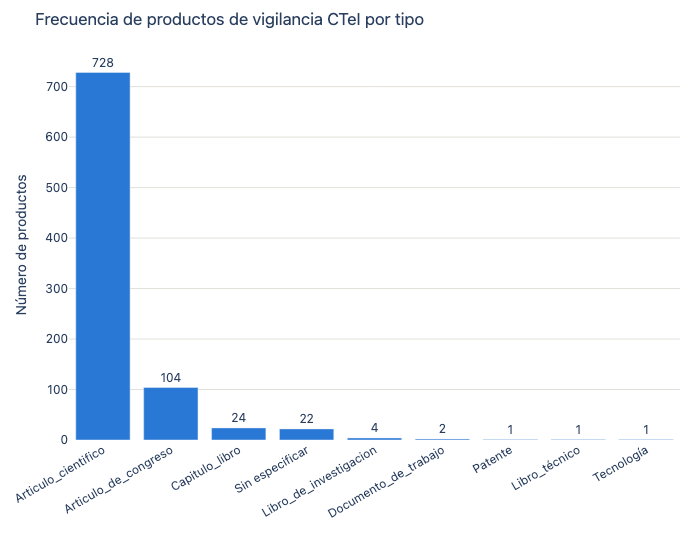

In [1]:
#| label: cell-tipo-frecuencia
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Vigilancia_CTeI"

df = pd.read_csv(CSV_URL)
tipo = df["TIPO"].fillna("Sin especificar")
counts = tipo.value_counts()

fig = go.Figure(go.Bar(
    x=counts.index,
    y=counts.values,
    marker_color="#2a78d6",
    text=counts.values,
    textposition="outside",
    hovertemplate="<b>%{x}</b><br>%{y} producto(s)<extra></extra>",
))
fig.update_layout(
    title="Frecuencia de productos de vigilancia CTeI por tipo",
    yaxis_title="N\u00famero de productos",
    margin=dict(l=50, r=20, t=50, b=110),
    height=550,
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
    plot_bgcolor="white",
)
fig.update_xaxes(tickangle=-30)
fig.update_yaxes(gridcolor="#e1e0d9")
fig.show()


## Panorama general

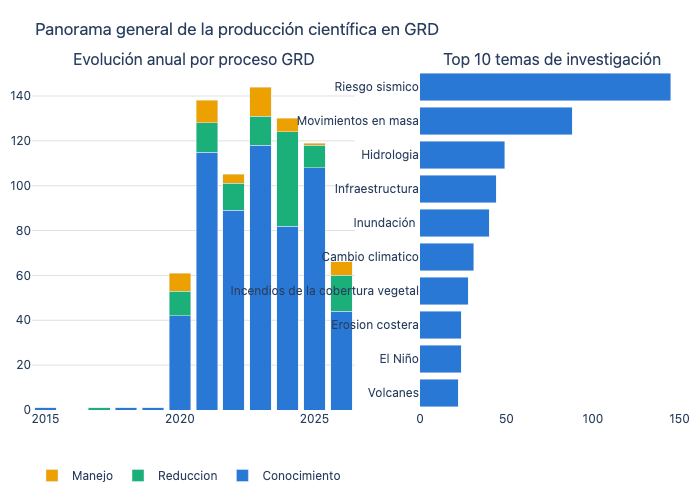

In [2]:
#| label: cell-vigilancia-resumen
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Vigilancia_CTeI"
df = pd.read_csv(CSV_URL)

from plotly.subplots import make_subplots

PROCESO_COLORS = {"Conocimiento": "#2a78d6", "Reduccion": "#1baf7a", "Manejo": "#eda100"}
sub = df.dropna(subset=["A\u00d1O", "PROCESO"])
sub = sub[sub["PROCESO"].isin(PROCESO_COLORS)]
sub["A\u00d1O"] = sub["A\u00d1O"].astype(int)
pivot = sub.groupby(["A\u00d1O", "PROCESO"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=list(PROCESO_COLORS)).reindex(
    range(int(sub["A\u00d1O"].min()), int(sub["A\u00d1O"].max()) + 1), fill_value=0
)

temas = df["TEMA"].dropna().value_counts().head(10).sort_values()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Evoluci\u00f3n anual por proceso GRD", "Top 10 temas de investigaci\u00f3n"),
    column_widths=[0.55, 0.45],
)
for proceso, color in PROCESO_COLORS.items():
    fig.add_trace(
        go.Bar(x=pivot.index, y=pivot[proceso], name=proceso, marker_color=color,
               hovertemplate=f"<b>{proceso}</b><br>%{{x}}: %{{y}}<extra></extra>"),
        row=1, col=1,
    )
fig.add_trace(
    go.Bar(x=temas.values, y=temas.index, orientation="h", marker_color="#2a78d6",
           showlegend=False, hovertemplate="<b>%{y}</b><br>%{x} productos<extra></extra>"),
    row=1, col=2,
)
fig.update_layout(
    barmode="stack",
    title="Panorama general de la producci\u00f3n cient\u00edfica en GRD",
    height=500,
    margin=dict(l=10, r=10, t=70, b=70),
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
    legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="left", x=0),
    plot_bgcolor="white",
)
fig.update_yaxes(gridcolor="#e1e0d9", row=1, col=1)
fig.show()


## Evolución temporal por proceso

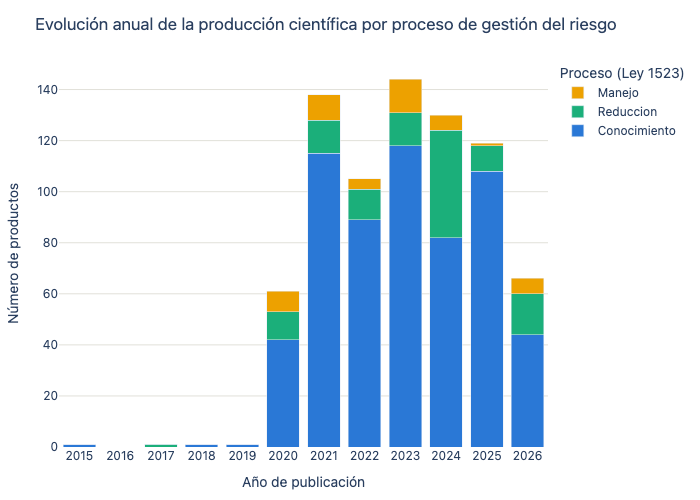

In [3]:
#| label: cell-evolucion-temporal
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Vigilancia_CTeI"
df = pd.read_csv(CSV_URL)

PROCESO_COLORS = {"Conocimiento": "#2a78d6", "Reduccion": "#1baf7a", "Manejo": "#eda100"}
sub = df.dropna(subset=["A\u00d1O", "PROCESO"])
sub = sub[sub["PROCESO"].isin(PROCESO_COLORS)]
sub["A\u00d1O"] = sub["A\u00d1O"].astype(int)
pivot = sub.groupby(["A\u00d1O", "PROCESO"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=list(PROCESO_COLORS)).reindex(
    range(int(sub["A\u00d1O"].min()), int(sub["A\u00d1O"].max()) + 1), fill_value=0
)

fig = go.Figure()
for proceso, color in PROCESO_COLORS.items():
    fig.add_trace(go.Bar(
        x=pivot.index, y=pivot[proceso], name=proceso, marker_color=color,
        hovertemplate=f"<b>{proceso}</b><br>A\u00f1o %{{x}}: %{{y}} producto(s)<extra></extra>",
    ))
fig.update_layout(
    barmode="stack",
    title="Evoluci\u00f3n anual de la producci\u00f3n cient\u00edfica por proceso de gesti\u00f3n del riesgo",
    xaxis_title="A\u00f1o de publicaci\u00f3n",
    yaxis_title="N\u00famero de productos",
    height=500,
    margin=dict(l=50, r=20, t=60, b=50),
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
    plot_bgcolor="white",
    legend_title="Proceso (Ley 1523)",
)
fig.update_yaxes(gridcolor="#e1e0d9")
fig.update_xaxes(dtick=1)
fig.show()


## Principales temas de investigación

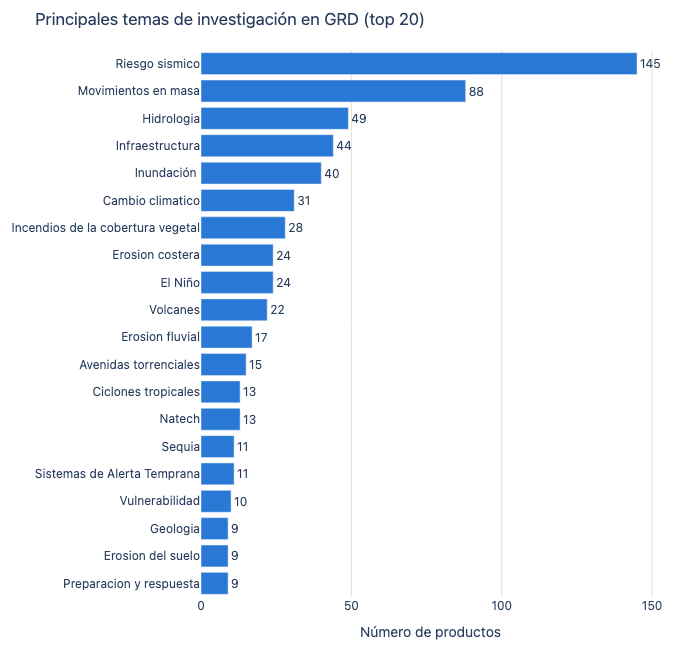

In [4]:
#| label: cell-top-temas
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Vigilancia_CTeI"
df = pd.read_csv(CSV_URL)

temas = df["TEMA"].dropna().value_counts().head(20).sort_values()

fig = go.Figure(go.Bar(
    x=temas.values, y=temas.index, orientation="h", marker_color="#2a78d6",
    text=temas.values, textposition="outside",
    hovertemplate="<b>%{y}</b><br>%{x} producto(s)<extra></extra>",
))
fig.update_layout(
    title="Principales temas de investigaci\u00f3n en GRD (top 20)",
    xaxis_title="N\u00famero de productos",
    height=650,
    margin=dict(l=180, r=40, t=50, b=40),
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
    plot_bgcolor="white",
)
fig.update_xaxes(gridcolor="#e1e0d9")
fig.show()


## Instituciones colombianas

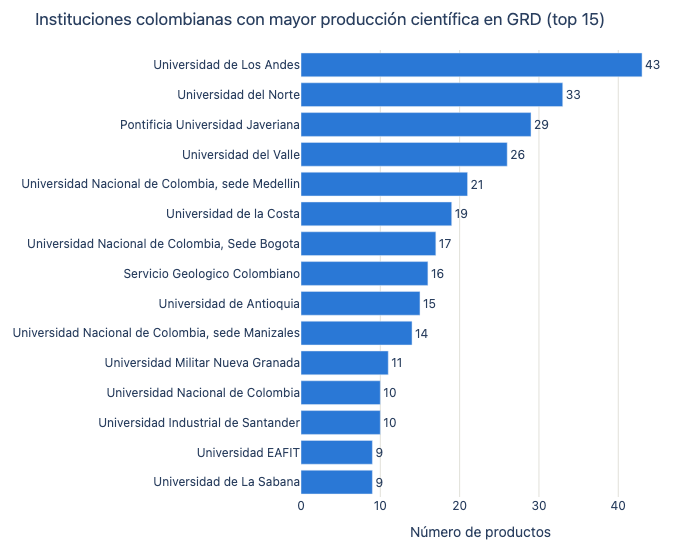

In [5]:
#| label: cell-top-instituciones
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Vigilancia_CTeI"
df = pd.read_csv(CSV_URL)

inst = df["INSTITUCION COLOMBIANA"].dropna().value_counts().head(15).sort_values()

fig = go.Figure(go.Bar(
    x=inst.values, y=inst.index, orientation="h", marker_color="#2a78d6",
    text=inst.values, textposition="outside",
    hovertemplate="<b>%{y}</b><br>%{x} producto(s)<extra></extra>",
))
fig.update_layout(
    title="Instituciones colombianas con mayor producci\u00f3n cient\u00edfica en GRD (top 15)",
    xaxis_title="N\u00famero de productos",
    height=550,
    margin=dict(l=280, r=40, t=50, b=40),
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
    plot_bgcolor="white",
)
fig.update_xaxes(gridcolor="#e1e0d9")
fig.show()


## Principales revistas/fuentes

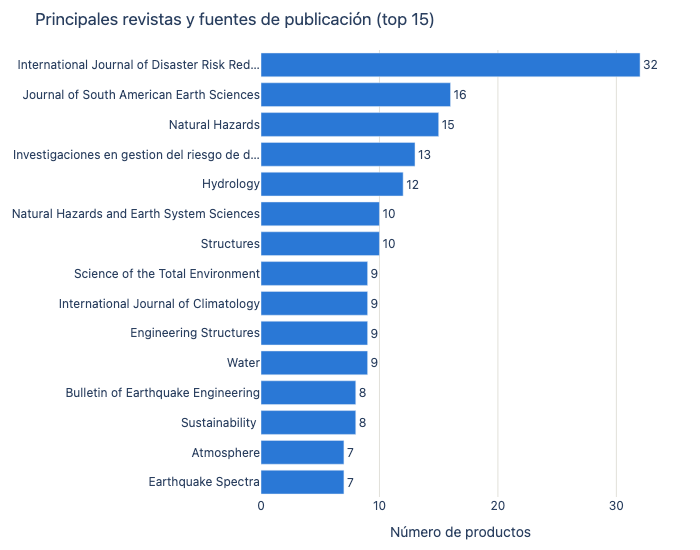

In [6]:
#| label: cell-top-revistas
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Vigilancia_CTeI"
df = pd.read_csv(CSV_URL)

fuentes = df["FUENTE"].dropna().value_counts().head(15).sort_values()
labels = [n if len(n) <= 45 else n[:42] + "\u2026" for n in fuentes.index]

fig = go.Figure(go.Bar(
    x=fuentes.values, y=labels, orientation="h", marker_color="#2a78d6",
    text=fuentes.values, textposition="outside",
    hovertemplate="<b>%{y}</b><br>%{x} producto(s)<extra></extra>",
))
fig.update_layout(
    title="Principales revistas y fuentes de publicaci\u00f3n (top 15)",
    xaxis_title="N\u00famero de productos",
    height=550,
    margin=dict(l=260, r=40, t=50, b=40),
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
    plot_bgcolor="white",
)
fig.update_xaxes(gridcolor="#e1e0d9")
fig.show()


## Distribución geográfica por departamento

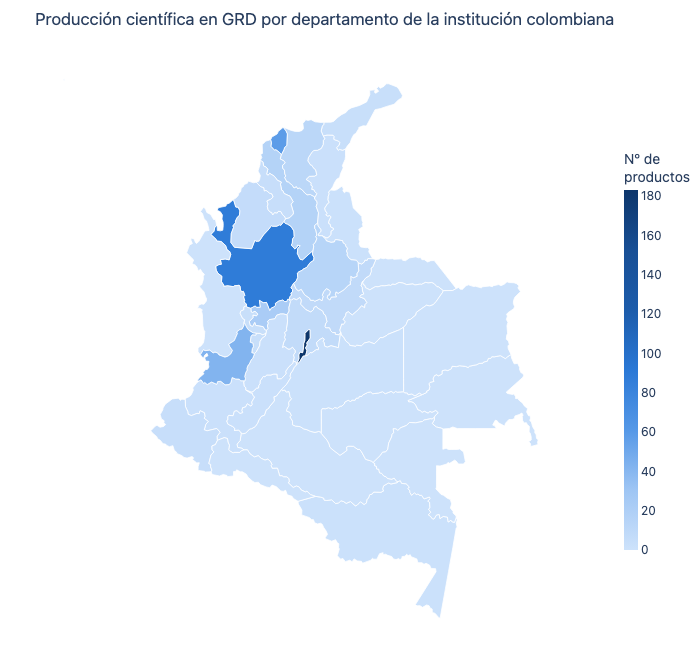

In [7]:
#| label: cell-mapa-vigilancia
import json
import urllib.request

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Vigilancia_CTeI"
df = pd.read_csv(CSV_URL)

GEOJSON_URL = "https://raw.githubusercontent.com/caticoa3/colombia_mapa/master/co_2018_MGN_DPTO_POLITICO.geojson"
with urllib.request.urlopen(GEOJSON_URL) as resp:
    geo = json.load(resp)

# Reconcile the free-text DEPARTAMENTO column (57 raw variants: accent inconsistencies,
# city names, faculty/institute names, foreign countries, explicit "no encontrado") with
# the official DIVIPOLA department names used by the geojson.
FIX = {
    "Antioqu\u00eda": "Antioquia", "Bogot\u00e1": "Bogot\u00e1 D.C.", "Bogot\u00e1, D.C.": "Bogot\u00e1 D.C.",
    "Bolivar": "Bol\u00edvar", "Guajira": "La Guajira", "Medellin": "Antioquia",
    "Quindio": "Quind\u00edo", "San Andr\u00e9s y Providencia": "San Andr\u00e9s, Providencia y Santa Catalina",
}
# Multi-department credits (e.g. co-authored across two departments) count toward both.
COMBO = {"Bol\u00edvar / Atl\u00e1ntico": ["Bol\u00edvar", "Atl\u00e1ntico"]}
# Foreign countries, generic faculty/institute names, and explicit "unknown" placeholders
# carry no usable department-level geography and are excluded from the map.
EXCLUDE = {
    "#NAME?", "Alemania", "Arabia Saudita", "Argentina", "Cambridge, UK", "Chile",
    "Colombia / Mexico", "Ecuador", "Espa\u00f1a", "Francia", "Japon", "Mexico", "M\u00e9xico",
    "N/D", "No aplica", "No encontrado",
    "CENIGAA (Centro de Investigaciones GeoAgroAmbiental)",
    "Departamento de F\u00edsica y Geociencias",
    "Departamento de Geociencias y Medio Ambiente",
    "Departamento de Ingenier\u00eda Civil / Facultad de Ingenier\u00eda",
    "Escuela de Ciencias e Ingenier\u00eda \u2013 Programa de Ciencias del Sistema Tierra",
    "Facultad de Ingenier\u00eda", "Observatorio Astron\u00f3mico Nacional", "Portugal",
}

NAME_MAP = {
    "AMAZONAS": "Amazonas", "ANTIOQUIA": "Antioquia", "ARAUCA": "Arauca",
    "ARCHIPI\u00c9LAGO DE SAN ANDR\u00c9S, PROVIDENCIA Y SANTA CATALINA": "San Andr\u00e9s, Providencia y Santa Catalina",
    "ATL\u00c1NTICO": "Atl\u00e1ntico", "BOGOT\u00c1, D.C.": "Bogot\u00e1 D.C.", "BOL\u00cdVAR": "Bol\u00edvar", "BOYAC\u00c1": "Boyac\u00e1",
    "CALDAS": "Caldas", "CAQUET\u00c1": "Caquet\u00e1", "CASANARE": "Casanare", "CAUCA": "Cauca", "CESAR": "Cesar",
    "CHOC\u00d3": "Choc\u00f3", "CUNDINAMARCA": "Cundinamarca", "C\u00d3RDOBA": "C\u00f3rdoba", "GUAIN\u00cdA": "Guain\u00eda",
    "GUAVIARE": "Guaviare", "HUILA": "Huila", "LA GUAJIRA": "La Guajira", "MAGDALENA": "Magdalena",
    "META": "Meta", "NARI\u00d1O": "Nari\u00f1o", "NORTE DE SANTANDER": "Norte de Santander", "PUTUMAYO": "Putumayo",
    "QUINDIO": "Quind\u00edo", "RISARALDA": "Risaralda", "SANTANDER": "Santander", "SUCRE": "Sucre",
    "TOLIMA": "Tolima", "VALLE DEL CAUCA": "Valle del Cauca", "VAUP\u00c9S": "Vaup\u00e9s", "VICHADA": "Vichada",
}
for f in geo["features"]:
    f["properties"]["name"] = NAME_MAP[f["properties"]["DPTO_CNMBR"]]

from collections import Counter, defaultdict
counts = Counter()
top_temas = defaultdict(Counter)
for _, row in df.dropna(subset=["DEPARTAMENTO"]).iterrows():
    raw = row["DEPARTAMENTO"].strip()
    depts = COMBO.get(raw)
    if depts is None:
        if raw in EXCLUDE:
            continue
        depts = [FIX.get(raw, raw)]
    for d in depts:
        if d in NAME_MAP.values():
            counts[d] += 1
            if pd.notna(row["TEMA"]):
                top_temas[d][row["TEMA"]] += 1

all_names = sorted(set(NAME_MAP.values()))
count_list = [int(counts.get(n, 0)) for n in all_names]
hover_temas = [
    "<br>".join(f"&#8226; {t}" for t, _ in top_temas[n].most_common(3)) or "Sin tema registrado"
    for n in all_names
]

max_count = max(count_list)
SEQ = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#184f95", "#0d366b"]
colorscale = [[i / (len(SEQ) - 1), c] for i, c in enumerate(SEQ)]

fig = go.Figure(go.Choropleth(
    geojson=geo,
    featureidkey="properties.name",
    locations=all_names,
    z=count_list,
    zmin=0, zmax=max_count,
    colorscale=colorscale,
    marker_line_color="white",
    marker_line_width=0.8,
    customdata=hover_temas,
    hovertemplate="<b>%{location}</b><br>%{z} producto(s)<br>%{customdata}<extra></extra>",
    colorbar=dict(title="N\u00ba de<br>productos", thickness=14, len=0.7),
))
fig.update_geos(fitbounds="locations", visible=False, projection_type="mercator")
fig.update_layout(
    title="Producci\u00f3n cient\u00edfica en GRD por departamento de la instituci\u00f3n colombiana",
    margin=dict(l=0, r=0, t=50, b=0),
    height=650,
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
)
fig.show()
